# 1. Project Introduction

### Project Overview
This project is centered on the **NGA-West2 (Next Generation Attenuation for Western United States)** earthquake ground-motion database. The NGA-West2 flatfile, compiled by the Pacific Earthquake Engineering Research Center (PEER), contains worldwide shallow crustal earthquake records used extensively by earthquake engineers and seismologists to develop empirical ground-motion models (GMMs).

Our project draws inspiration from the Stanford University study by Alan Poulos and Rodrigo Silva-Lopez (*"Machine Learning Tools for Predicting Ground Motion Directionality"*). In that study, the authors explore how ground-shaking orientation varies across geographic space and attempt to predict the absolute difference between orientations of maximum shaking ($\Delta\theta = |\theta_i - \theta_j|$) between pairs of recording stations.

### Role of This Notebook (Phase 1: Data & Feature Engineering)
This notebook is dedicated entirely to the **Data Inspection, Cleaning, and Feature Preparation** phase of the project:
1. **Data Inspection**: Systematically load and understand the 274 attributes and 21,540 ground-motion records in the flatfile.
2. **Quality & Anomaly Diagnostics**: Detect hidden sentinel missing values (`-999`), constant columns, duplicate records, and unused columns.
3. **Seismological Feature Selection**: Identify physically meaningful attributes covering earthquake source properties, site soil conditions, propagation distances, and ground-motion intensities.
4. **Data Cleaning**: Filter out non-significant records using defensible engineering criteria (e.g., minimum magnitude threshold of $M_w \ge 5.0$ as established in the literature) and handle missing records without corrupting the dataset.
5. **Feature Preparation**: Identify categorical features for encoding and separate raw features from training-set-dependent scaling to avoid data leakage.
6. **Dataset Export**: Export a pristine, ML-ready dataset (`cleaned_NGA_West2_d050.csv`) as variable `cleaned_df` for team members to use in subsequent modeling tasks.

### Important Boundary Conditions
- **No Model Training in this Notebook**: Regression and Neural Network model training are reserved for subsequent phases.
- **No Artificial $\Delta\theta$ Generation**: Directional orientation of maximum ground shaking ($\theta$) requires processing raw two-component accelerogram waveforms (RotD100). The public flatfile provided (`RotD50_d050`) contains median orientation-independent ground motions, not orientation angles. Directivity parameters such as `Theta.D` represent geometric source-to-site angles and must NOT be confused with ground-motion directionality. Therefore, $\Delta\theta$ is not artificially invented here.

# 2. Import Required Libraries

We import standard, beginner-friendly Python data science libraries.
- `pandas` for tabular data manipulation and cleaning.
- `numpy` for numerical array operations.
- `matplotlib.pyplot` for creating figures and plots.
- `seaborn` for statistical visualizations.
- `openpyxl` for inspecting Excel workbook structures.

In [1]:
#pip install notebook ipykernel pandas numpy matplotlib seaborn openpyxl scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

All required libraries have been loaded successfully.

# 3. Load the Dataset

We locate the raw Excel file `Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx` in the project folder. First, we inspect the available sheets without loading the entire file into memory. Then, we load the active sheet into a pandas DataFrame named `raw_df`.

In [3]:
excel_path = "dataset/Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx"
wb = openpyxl.load_workbook(excel_path, read_only=True)
available_sheets = wb.sheetnames
print("Available Sheet Names:", available_sheets)
selected_sheet = available_sheets[0]
print("Selected Sheet for Analysis:", selected_sheet)
wb.close()

Available Sheet Names: ['ROTD50_d050']
Selected Sheet for Analysis: ROTD50_d050


Now we load the selected sheet into pandas and check its dimensions.

In [4]:
raw_df = pd.read_excel(excel_path, sheet_name=selected_sheet)
print("DataFrame Shape (Rows, Columns):", raw_df.shape)
print("Total Number of Rows:", raw_df.shape[0])
print("Total Number of Columns:", raw_df.shape[1])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


DataFrame Shape (Rows, Columns): (21540, 274)
Total Number of Rows: 21540
Total Number of Columns: 274


Displaying the first 5 records of the raw dataset:

In [5]:
raw_df.head()

,Record Sequence Number,EQID,Earthquake Name,YEAR,MODY,HRMN,Station Name,Station Sequence Number,Station ID No.,Earthquake Magnitude,...,Instrument Nat. Freq.,Instrument Damping,Instrument Type,Quality_Flag,Spectra Quality Flag,Late S-trigger,Late P-trigger,Idirectivity,Tp,Ry 2
0,1,1,"Helena, Montana-01",1935,1031,1838,Carroll College,197,2022,6.0,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0,8.046386
1,2,2,"Helena, Montana-02",1935,1031,1918,Helena Fed Bldg,198,2229,6.0,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0,0.155745
2,3,3,Humbolt Bay,1937,207,442,Ferndale City Hall,133,1023,5.8,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0,-38.820722
3,4,4,Imperial Valley-01,1938,606,242,El Centro Array #9,75,117,5.0,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0,23.958844
4,5,5,Northwest Calif-01,1938,912,610,Ferndale City Hall,133,1023,5.5,...,-999.0,-999.0,-999,-999,0,-999,-999,0,-999.0,51.112544


Displaying the last 5 records of the raw dataset:

In [6]:
raw_df.tail()

,Record Sequence Number,EQID,Earthquake Name,YEAR,MODY,HRMN,Station Name,Station Sequence Number,Station ID No.,Earthquake Magnitude,...,Instrument Nat. Freq.,Instrument Damping,Instrument Type,Quality_Flag,Spectra Quality Flag,Late S-trigger,Late P-trigger,Idirectivity,Tp,Ry 2
21535,21536,1265,51177103,2006,1223,649,San Andreas Cal.,100433,JSA,3.6,...,223.9758,0.6971,a,-999,0,-999,-999,-999,-999.0,-999.000000
21536,21537,1265,51177103,2006,1223,649,Stanford Telescope,100448,JSFB,3.6,...,223.9758,0.6971,a,-999,0,-999,-999,-999,-999.0,-999.000000
21537,21538,1265,51177103,2006,1223,649,San Pedro Valley,100331,JSP,3.6,...,223.9758,0.6971,a,-999,0,-999,-999,-999,-999.0,-999.000000
21538,21539,1265,51177103,2006,1223,649,Point Molate,100054,CPM,3.6,...,49.9901,0.7071,a,-999,0,-999,-999,-999,-999.0,-999.000000
21539,21540,179,"Parkfield-02, CA",2004,928,1715,Diablo Canyon Power Plant ESTA27,100606,DCPP,6.0,...,-999.0000,-999.0000,-999,-999,0,-999,-999,0,-999.0,34.127872


# 4. Understand the Dataset

Here we examine the column types, count numerical versus categorical features, compute descriptive statistics for prominent seismic variables, and construct a column-level summary table.

In [7]:
numerical_columns = raw_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = raw_df.select_dtypes(include=["object"]).columns.tolist()

print("Number of Numerical Columns:", len(numerical_columns))
print("Number of Categorical/Object Columns:", len(categorical_columns))

Number of Numerical Columns: 230
Number of Categorical/Object Columns: 44


Creating a summary table of dataset columns showing data types, missing value count (as initially recognized by pandas), and unique value counts for the first 30 columns:

In [8]:
column_summary_df = pd.DataFrame({
    "Column Name": raw_df.columns,
    "Data Type": raw_df.dtypes.values,
    "Standard Missing (NaN)": raw_df.isna().sum().values,
    "Unique Values Count": raw_df.nunique().values
})

column_summary_df.head(30)

,Column Name,Data Type,Standard Missing (NaN),Unique Values Count
0,Record Sequence Number,int64,0,21540
1,EQID,int64,0,600
2,Earthquake Name,object,0,608
3,YEAR,int64,0,59
4,MODY,int64,0,270
5,HRMN,int64,0,483
6,Station Name,object,0,4161
7,Station Sequence Number,int64,0,4151
8,Station ID No.,object,0,3039
9,Earthquake Magnitude,float64,0,223


Computing descriptive statistics for key earthquake, site, distance, and ground motion variables:

In [9]:
primary_cols = [
    "Earthquake Magnitude",
    "Hypocenter Depth (km)",
    "Vs30 (m/s) selected for analysis",
    "Joyner-Boore Dist. (km)",
    "Campbell R Dist. (km)",
    "ClstD (km)",
    "PGA (g)",
    "PGV (cm/sec)",
    "PGD (cm)"
]

raw_df[primary_cols].describe()

,Earthquake Magnitude,Hypocenter Depth (km),Vs30 (m/s) selected for analysis,Joyner-Boore Dist. (km),Campbell R Dist. (km),ClstD (km),PGA (g),PGV (cm/sec),PGD (cm)
count,21540.000000,21540.000000,21540.000000,21540.000000,21540.000000,21540.000000,21540.000000,21540.000000,21540.000000
mean,4.397750,9.264240,466.500653,112.949361,-338.370578,113.892670,-9.432880,-6.747611,-8.025124
std,23.724029,24.126243,203.720757,115.341657,550.860696,114.874689,96.764056,97.375799,97.066819
min,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000
25%,3.900000,7.180000,337.942500,44.540000,-999.000000,45.837500,0.000336,0.014131,0.001382
50%,4.500000,9.270000,416.520000,89.135000,33.745000,89.745000,0.002617,0.118695,0.011808
75%,6.200000,12.500000,572.530000,158.875000,106.512500,159.262500,0.019121,1.769275,0.574140
max,7.900000,81.000000,2100.000000,1532.660000,1156.990000,1532.660000,1.768300,256.620000,365.920000


Notice in the descriptive table above that the minimum value for `Earthquake Magnitude`, `Hypocenter Depth (km)`, `Vs30`, `Joyner-Boore Dist. (km)`, and `PGA (g)` is `-999.0`. In the NGA-West2 database standard, `-999` indicates a missing or unmeasured value. We investigate this in detail in the next section.

# 5. Data Quality Check

A thorough data quality audit requires checking for:
1. Duplicate rows across the entire dataset.
2. Duplicate records based on primary identifiers like `Record Sequence Number`.
3. Sentinel missing values (`-999` and `-999.0`) used in place of standard nulls.
4. Constant columns containing no variance or information.
5. Columns labeled explicitly as unused in the database.
6. Visualizations of missing values, distributions, and boxplots for outliers.

In [10]:
full_duplicates = raw_df.duplicated().sum()
rsn_duplicates = raw_df["Record Sequence Number"].duplicated().sum()

print("Full duplicate rows:", full_duplicates)
print("Duplicate Record Sequence Numbers:", rsn_duplicates)

Full duplicate rows: 0
Duplicate Record Sequence Numbers: 0


We search for occurrences of sentinel codes (`-999`, `-999.0`, and `"-999"`):

In [11]:
sentinel_count_int = (raw_df == -999).sum().sum()
sentinel_count_float = (raw_df == -999.0).sum().sum()
sentinel_count_str = (raw_df == "-999").sum().sum()

print("Occurrences of integer -999:", sentinel_count_int)
print("Occurrences of float -999.0:", sentinel_count_float)
print("Occurrences of string '-999':", sentinel_count_str)

Occurrences of integer -999: 1455687
Occurrences of float -999.0: 1455687
Occurrences of string '-999': 30060


Next, we scan for constant columns (columns with 1 or fewer unique values) and columns designated as unused:

In [12]:
constant_cols = [col for col in raw_df.columns if raw_df[col].nunique() <= 1]
print("Constant Columns (no variation):", constant_cols)

unused_cols = [col for col in raw_df.columns if "unused" in col.lower() or "not used" in col.lower()]
print("Unused Columns explicitly labeled:", unused_cols)

Constant Columns (no variation): ['d', 'Unused Column', 'Unused Column.1', 'Unused Column.2', 'Unused Column.3']
Unused Columns explicitly labeled: ['Unused Column', 'Unused Column.1', 'Unused Column.2', 'Unused Column.3', 'Column Not Used']


To accurately evaluate missing data, we create a working copy `df_working` where sentinel `-999` values are mapped to standard `np.nan`:

In [13]:
df_working = raw_df.copy()
df_working = df_working.replace(-999, np.nan)
df_working = df_working.replace(-999.0, np.nan)
df_working = df_working.replace("-999", np.nan)
print("Sentinel -999 replacement completed. Total NaNs across dataset:", df_working.isna().sum().sum())

Sentinel -999 replacement completed. Total NaNs across dataset: 1485749


### 5.1 Missing Value Visualization
We plot the true missing value percentages across prominent seismological features:

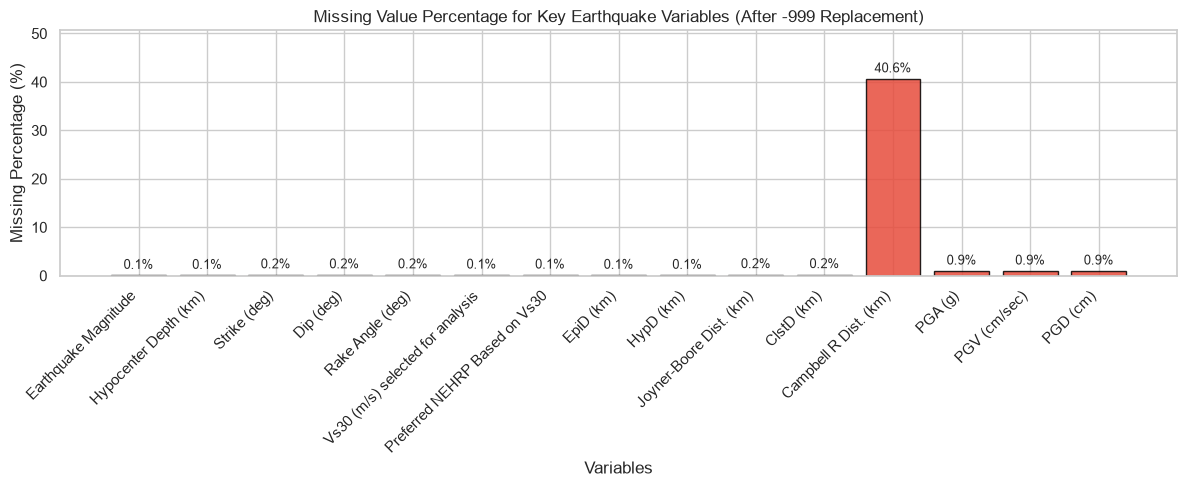

In [14]:
audit_features = [
    "Earthquake Magnitude", "Hypocenter Depth (km)", "Strike (deg)", "Dip (deg)", "Rake Angle (deg)",
    "Vs30 (m/s) selected for analysis", "Preferred NEHRP Based on Vs30",
    "EpiD (km)", "HypD (km)", "Joyner-Boore Dist. (km)", "ClstD (km)", "Campbell R Dist. (km)",
    "PGA (g)", "PGV (cm/sec)", "PGD (cm)"
]

missing_percentages = (df_working[audit_features].isna().sum() / len(df_working)) * 100

plt.figure(figsize=(12, 5))
bars = plt.bar(audit_features, missing_percentages, color="#e74c3c", edgecolor="black", alpha=0.85)
plt.title("Missing Value Percentage for Key Earthquake Variables (After -999 Replacement)")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Variables")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(missing_percentages) + 10)
for bar in bars:
    yval = bar.get_height()
    if yval > 0.05:
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{yval:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Distribution Plots for Important Numerical Variables
We visualize the distributions of magnitude, soil shear-wave velocity ($V_{s30}$), closest distance to rupture ($ClstD$), and peak ground acceleration ($PGA$):

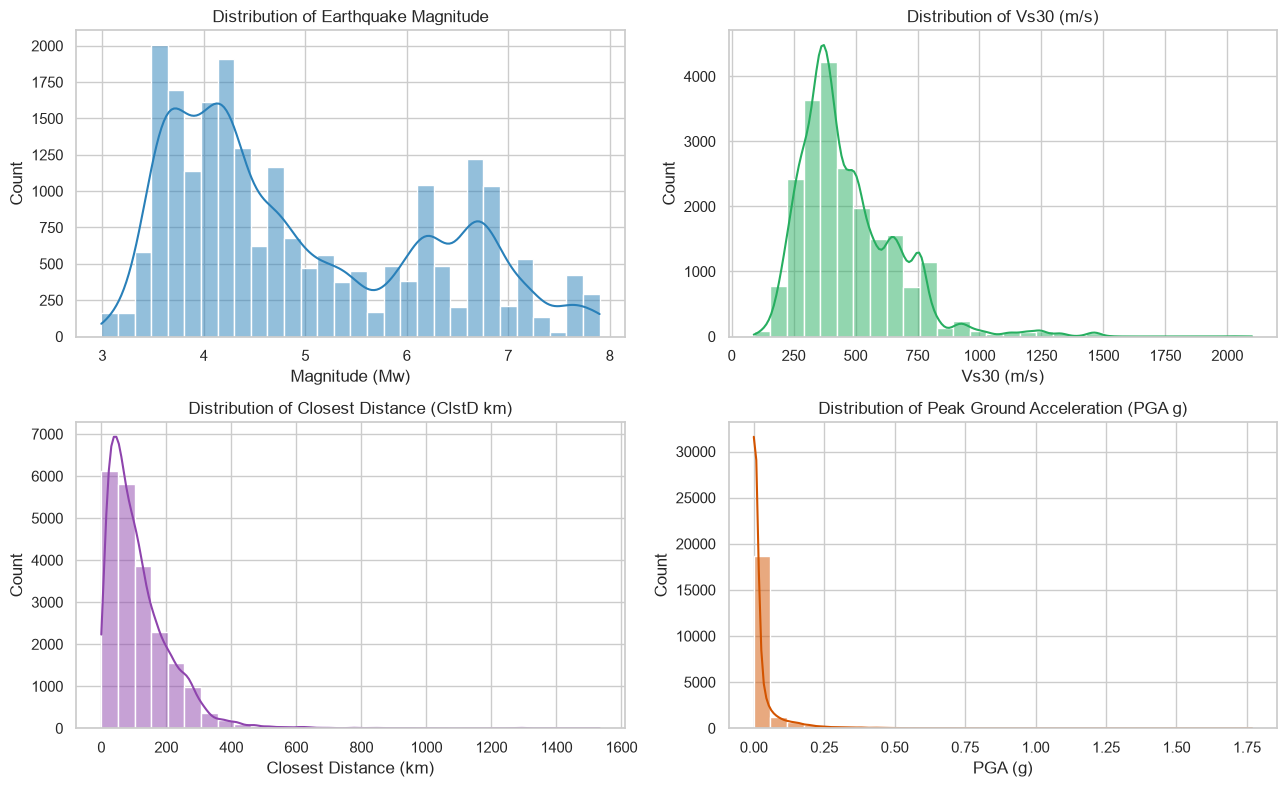

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df_working["Earthquake Magnitude"].dropna(), bins=30, kde=True, ax=axes[0, 0], color="#2980b9")
axes[0, 0].set_title("Distribution of Earthquake Magnitude")
axes[0, 0].set_xlabel("Magnitude (Mw)")

sns.histplot(df_working["Vs30 (m/s) selected for analysis"].dropna(), bins=30, kde=True, ax=axes[0, 1], color="#27ae60")
axes[0, 1].set_title("Distribution of Vs30 (m/s)")
axes[0, 1].set_xlabel("Vs30 (m/s)")

sns.histplot(df_working["ClstD (km)"].dropna(), bins=30, kde=True, ax=axes[1, 0], color="#8e44ad")
axes[1, 0].set_title("Distribution of Closest Distance (ClstD km)")
axes[1, 0].set_xlabel("Closest Distance (km)")

sns.histplot(df_working["PGA (g)"].dropna(), bins=30, kde=True, ax=axes[1, 1], color="#d35400")
axes[1, 1].set_title("Distribution of Peak Ground Acceleration (PGA g)")
axes[1, 1].set_xlabel("PGA (g)")

plt.tight_layout()
plt.show()

### 5.3 Boxplots for Outlier Diagnosis
Boxplots provide an overview of the spread and extreme observations for these physical variables:

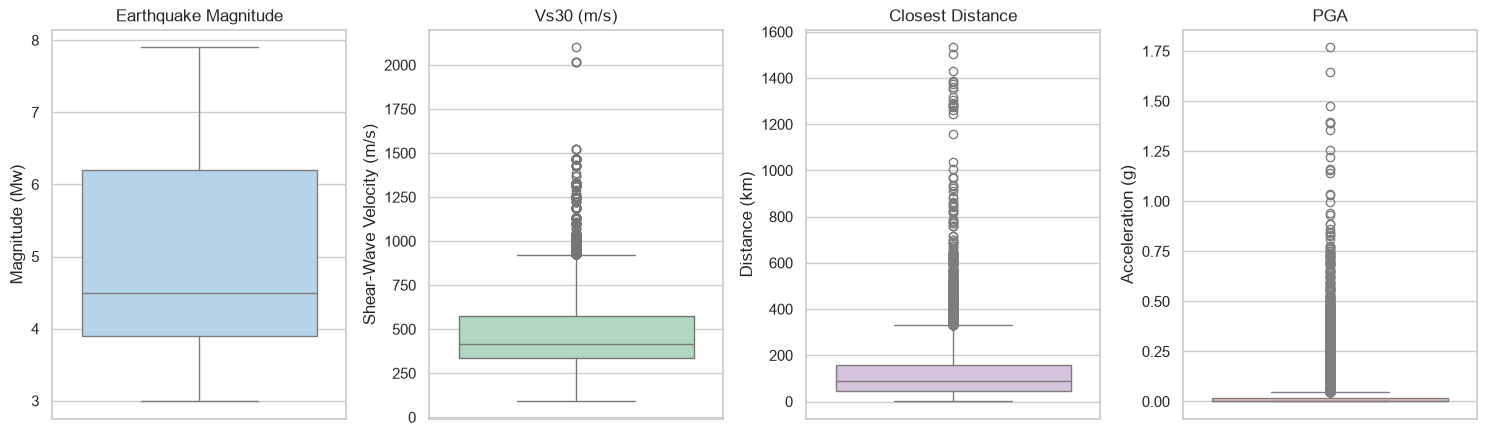

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))

sns.boxplot(y=df_working["Earthquake Magnitude"].dropna(), ax=axes[0], color="#aed6f1")
axes[0].set_title("Earthquake Magnitude")
axes[0].set_ylabel("Magnitude (Mw)")

sns.boxplot(y=df_working["Vs30 (m/s) selected for analysis"].dropna(), ax=axes[1], color="#a9dfbf")
axes[1].set_title("Vs30 (m/s)")
axes[1].set_ylabel("Shear-Wave Velocity (m/s)")

sns.boxplot(y=df_working["ClstD (km)"].dropna(), ax=axes[2], color="#d7bde2")
axes[2].set_title("Closest Distance")
axes[2].set_ylabel("Distance (km)")

sns.boxplot(y=df_working["PGA (g)"].dropna(), ax=axes[3], color="#f5b7b1")
axes[3].set_title("PGA")
axes[3].set_ylabel("Acceleration (g)")

plt.tight_layout()
plt.show()

# 6. Identify Important Project Variables

Based strictly on the actual columns present in the NGA-West2 dataset, we categorize candidate attributes into the functional domains required for earthquake ground-motion analysis:

1. **Earthquake Information**: Unique event identifier (`EQID`), name, year, and record sequence number (`Record Sequence Number`).
2. **Site / Station Information**: Station identifier (`Station ID  No.`), station name (`Station Name`).
3. **Magnitude**: Moment magnitude (`Earthquake Magnitude`), magnitude determination type (`Magnitude Type`).
4. **Distance Measures**: Epicentral distance (`EpiD`), hypocentral distance (`HypD`), Joyner-Boore distance (`Joyner-Boore Dist. (km)`), closest distance to ruptured fault plane (`ClstD (km)`), Campbell distance (`Campbell R Dist. (km)`).
5. **Site / Soil Properties**: Time-averaged shear-wave velocity in upper 30m (`Vs30 (m/s) selected for analysis`), NEHRP site classification (`Preferred NEHRP Based on Vs30`).
6. **Ground-Motion Measures**: Peak ground acceleration (`PGA (g)`), peak ground velocity (`PGV (cm/sec)`), peak ground displacement (`PGD (cm)`).
7. **Geographical Information**: Earthquake hypocenter coordinates (`Hypocenter Latitude`, `Hypocenter Longitude`), station coordinates (`Station Latitude`, `Station Longitude`).
8. **Horizontal Recording Information**: Azimuths of horizontal instrument channels (`H1 azimth`, `H2 azimith`).

Below is the structured dictionary table of candidate variables, their physical meaning, data type, and Keep/Drop recommendation:

In [17]:
variable_dictionary = [
    {"Column": "Record Sequence Number", "Meaning/Role": "Unique ground motion record ID in NGA-West2", "Data Type": "Integer", "Keep/Drop": "Keep", "Reason": "Primary unique key for tracking records"},
    {"Column": "EQID", "Meaning/Role": "Earthquake event ID", "Data Type": "Integer", "Keep/Drop": "Keep", "Reason": "Crucial for grouping stations that recorded the same event"},
    {"Column": "Earthquake Name", "Meaning/Role": "Name of the earthquake event", "Data Type": "String", "Keep/Drop": "Keep", "Reason": "Useful metadata for inspection and reporting"},
    {"Column": "YEAR", "Meaning/Role": "Year of occurrence", "Data Type": "Integer", "Keep/Drop": "Keep", "Reason": "Temporal metadata"},
    {"Column": "Station Name", "Meaning/Role": "Name of the seismic recording station", "Data Type": "String", "Keep/Drop": "Keep", "Reason": "Station identifier metadata"},
    {"Column": "Station Latitude", "Meaning/Role": "Latitude coordinate of recording station", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Required to compute inter-site separation distances"},
    {"Column": "Station Longitude", "Meaning/Role": "Longitude coordinate of recording station", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Required to compute inter-site separation distances"},
    {"Column": "Earthquake Magnitude", "Meaning/Role": "Moment magnitude (Mw) of earthquake", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Primary physical feature governing ground-motion energy"},
    {"Column": "Hypocenter Depth (km)", "Meaning/Role": "Focal depth of earthquake rupture initiation", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Governs path attenuation and wave propagation depth"},
    {"Column": "Hypocenter Latitude (deg)", "Meaning/Role": "Latitude coordinate of earthquake hypocenter", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Source location geometry"},
    {"Column": "Hypocenter Longitude (deg)", "Meaning/Role": "Longitude coordinate of earthquake hypocenter", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Source location geometry"},
    {"Column": "Strike (deg)", "Meaning/Role": "Strike angle of the fault rupture plane", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Fault rupture geometry and orientation"},
    {"Column": "Dip (deg)", "Meaning/Role": "Dip angle of the fault rupture plane", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Fault rupture geometry"},
    {"Column": "Rake Angle (deg)", "Meaning/Role": "Slip direction angle on fault plane", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Defines focal slip kinematics"},
    {"Column": "Mechanism Based on Rake Angle", "Meaning/Role": "Fault mechanism class (strike-slip, normal, reverse)", "Data Type": "Integer/Categorical", "Keep/Drop": "Keep", "Reason": "Standard seismological classification of faulting style"},
    {"Column": "Vs30 (m/s) selected for analysis", "Meaning/Role": "Shear-wave velocity in top 30 meters of soil", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Standard site amplification parameter in engineering"},
    {"Column": "Preferred NEHRP Based on Vs30", "Meaning/Role": "NEHRP soil category (A, B, C, D, E)", "Data Type": "String/Categorical", "Keep/Drop": "Keep", "Reason": "Categorical site condition parameter"},
    {"Column": "EpiD (km)", "Meaning/Role": "Epicentral distance from source to station", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Horizontal source-to-site distance"},
    {"Column": "HypD (km)", "Meaning/Role": "Hypocentral distance from focus to station", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Direct slant distance from source initiation"},
    {"Column": "Joyner-Boore Dist. (km)", "Meaning/Role": "Shortest distance to surface projection of fault", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Standard distance metric in modern GMMs"},
    {"Column": "ClstD (km)", "Meaning/Role": "Closest distance to rupture surface (Rrup)", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Fundamental distance metric in attenuation equations"},
    {"Column": "PGA (g)", "Meaning/Role": "Peak Ground Acceleration (RotD50)", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Primary ground-motion intensity measure"},
    {"Column": "PGV (cm/sec)", "Meaning/Role": "Peak Ground Velocity (RotD50)", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Key velocity-sensitive intensity measure"},
    {"Column": "PGD (cm)", "Meaning/Role": "Peak Ground Displacement (RotD50)", "Data Type": "Float", "Keep/Drop": "Keep", "Reason": "Displacement-sensitive intensity measure"},
    {"Column": "Campbell R Dist. (km)", "Meaning/Role": "Campbell distance measure", "Data Type": "Float", "Keep/Drop": "Drop", "Reason": "High missing rate (>40%) and redundant with ClstD and Rjb"},
    {"Column": "Unused Column", "Meaning/Role": "Empty placeholder column in database", "Data Type": "Float", "Keep/Drop": "Drop", "Reason": "Contains zero data"},
    {"Column": "Theta.D (deg)", "Meaning/Role": "Directivity model geometric azimuth angle", "Data Type": "Float", "Keep/Drop": "Drop", "Reason": "Directivity model parameter, not ground-motion directionality"}
]

variables_table = pd.DataFrame(variable_dictionary)
variables_table

,Column,Meaning/Role,Data Type,Keep/Drop,Reason
0,Record Sequence Number,Unique ground motion record ID in NGA-West2,Integer,Keep,Primary unique key for tracking records
1,EQID,Earthquake event ID,Integer,Keep,Crucial for grouping stations that recorded th...
2,Earthquake Name,Name of the earthquake event,String,Keep,Useful metadata for inspection and reporting
3,YEAR,Year of occurrence,Integer,Keep,Temporal metadata
4,Station Name,Name of the seismic recording station,String,Keep,Station identifier metadata
5,Station Latitude,Latitude coordinate of recording station,Float,Keep,Required to compute inter-site separation dist...
6,Station Longitude,Longitude coordinate of recording station,Float,Keep,Required to compute inter-site separation dist...
7,Earthquake Magnitude,Moment magnitude (Mw) of earthquake,Float,Keep,Primary physical feature governing ground-moti...
8,Hypocenter Depth (km),Focal depth of earthquake rupture initiation,Float,Keep,Governs path attenuation and wave propagation ...
9,Hypocenter Latitude (deg),Latitude coordinate of earthquake hypocenter,Float,Keep,Source location geometry


# 7. Initial Feature Selection

From the 274 total columns in the raw dataset, we form an initial feature subset aligned with the reference paper methodology:
- **Earthquake / Source Features**: `Earthquake Magnitude`, `Hypocenter Depth (km)`, `Hypocenter Latitude (deg)`, `Hypocenter Longitude (deg)`, `Strike (deg)`, `Dip (deg)`, `Rake Angle (deg)`, `Mechanism Based on Rake Angle`.
- **Propagation Distances**: `ClstD (km)`, `Joyner-Boore Dist. (km)`, `HypD (km)`, `EpiD (km)`.
- **Site / Soil Characteristics**: `Vs30 (m/s) selected for analysis`, `Preferred NEHRP Based on Vs30`.
- **Ground-Motion Intensity**: `PGA (g)`, `PGV (cm/sec)`, `PGD (cm)`.
- **Station Coordinates & Identifiers**: `Station Latitude`, `Station Longitude`, `Record Sequence Number`, `EQID`, `Earthquake Name`, `YEAR`, `Station Name`.

We drop:
- 111 response spectral acceleration columns (`T0.010S` to `T20.000S`) which are redundant with PGA and PGV at this stage.
- 45 columns with >80% missing data (e.g. `Static Stress Drop`, `Rise Time`, `Fault Rupture Area`).
- Directivity angle parameters such as `Theta.D` and `Phi.D` which are not directionality intensity orientations.
- Constant columns (`d`, `Unused Column`, etc.).

Note: Final forward/backward stepwise feature selection requires a calibrated regression model and target variable $\Delta\theta$, which will be performed in subsequent project phases.

In [18]:
feature_columns = [
    "Record Sequence Number",
    "EQID",
    "Earthquake Name",
    "YEAR",
    "Station Name",
    "Station Latitude",
    "Station Longitude",
    "Earthquake Magnitude",
    "Hypocenter Depth (km)",
    "Hypocenter Latitude (deg)",
    "Hypocenter Longitude (deg)",
    "Strike (deg)",
    "Dip (deg)",
    "Rake Angle (deg)",
    "Mechanism Based on Rake Angle",
    "Vs30 (m/s) selected for analysis",
    "Preferred NEHRP Based on Vs30",
    "EpiD (km)",
    "HypD (km)",
    "Joyner-Boore Dist. (km)",
    "ClstD (km)",
    "PGA (g)",
    "PGV (cm/sec)",
    "PGD (cm)"
]

df_selected = df_working[feature_columns].copy()
print("Number of Selected Features:", len(feature_columns))
print("Selected DataFrame Shape:", df_selected.shape)

Number of Selected Features: 24
Selected DataFrame Shape: (21540, 24)


Displaying the first 5 rows of the selected subset:

In [19]:
df_selected.head()

,Record Sequence Number,EQID,Earthquake Name,YEAR,Station Name,Station Latitude,Station Longitude,Earthquake Magnitude,Hypocenter Depth (km),Hypocenter Latitude (deg),...,Mechanism Based on Rake Angle,Vs30 (m/s) selected for analysis,Preferred NEHRP Based on Vs30,EpiD (km),HypD (km),Joyner-Boore Dist. (km),ClstD (km),PGA (g),PGV (cm/sec),PGD (cm)
0,1,1.0,"Helena, Montana-01",1935.0,Carroll College,46.580,-112.030,6.0,6.0,46.61,...,0.0,593.35,C,6.31,8.71,2.07,2.86,0.157020,10.05400,3.005200
1,2,2.0,"Helena, Montana-02",1935.0,Helena Fed Bldg,46.590,-112.040,6.0,6.0,46.62,...,0.0,551.82,C,6.31,8.71,2.09,2.92,0.046423,0.64978,0.035305
2,3,3.0,Humbolt Bay,1937.0,Ferndale City Hall,40.576,-124.263,5.8,10.0,40.40,...,0.0,219.31,D,73.49,74.17,71.28,71.57,0.040961,2.79070,0.402240
3,4,4.0,Imperial Valley-01,1938.0,El Centro Array #9,32.794,-115.549,5.0,16.0,32.90,...,0.0,213.44,D,33.20,36.86,32.44,34.98,0.018449,0.64551,0.056359
4,5,5.0,Northwest Calif-01,1938.0,Ferndale City Hall,40.576,-124.263,5.5,10.0,40.30,...,0.0,219.31,D,54.88,55.78,52.73,53.58,0.122180,6.56390,0.733060


# 8. Data Cleaning

We apply systematic, explainable cleaning rules based on domain principles and the reference paper:

1. **Step 1: Check and Remove Duplicates**: Ensure no identical rows or duplicate sequence numbers exist.
2. **Step 2: Filter for Engineering Significance ($M_w \ge 5.0$)**: In accordance with Poulos & Silva-Lopez (Section 3.1), ground motions from very small earthquakes ($M_w < 5.0$) do not cause significant structural shaking and are filtered out. This also removes unmeasured magnitude records.
3. **Step 3: Require Valid Ground-Motion Intensities**: Remove records missing `PGA (g)`, `PGV (cm/sec)`, or `PGD (cm)`.
4. **Step 4: Require Valid Site and Distance Attributes**: Remove records missing primary distance metrics (`ClstD (km)`), hypocenter depth, or site velocity (`Vs30`).

For every cleaning step, we show the exact row counts before and after the operation.

In [20]:
count_initial = len(df_selected)
print("Before cleaning:", count_initial, "rows")

df_step1 = df_selected.drop_duplicates()
count_step1 = len(df_step1)
print("After removing duplicate rows:", count_step1, "rows (Removed:", count_initial - count_step1, ")")

df_step2 = df_step1[df_step1["Earthquake Magnitude"] >= 5.0]
count_step2 = len(df_step2)
print("After filtering for Magnitude >= 5.0:", count_step2, "rows (Removed:", count_step1 - count_step2, ")")

df_step3 = df_step2.dropna(subset=["PGA (g)", "PGV (cm/sec)", "PGD (cm)"])
count_step3 = len(df_step3)
print("After requiring valid ground-motion intensities (PGA, PGV, PGD):", count_step3, "rows (Removed:", count_step2 - count_step3, ")")

df_step4 = df_step3.dropna(subset=["ClstD (km)", "Vs30 (m/s) selected for analysis", "Hypocenter Depth (km)"])
count_step4 = len(df_step4)
print("After requiring valid distance, depth, and Vs30:", count_step4, "rows (Removed:", count_step3 - count_step4, ")")

Before cleaning: 21540 rows
After removing duplicate rows: 21540 rows (Removed: 0 )
After filtering for Magnitude >= 5.0: 8495 rows (Removed: 13045 )
After requiring valid ground-motion intensities (PGA, PGV, PGD): 8409 rows (Removed: 86 )
After requiring valid distance, depth, and Vs30: 8391 rows (Removed: 18 )


Summary of cleaning progression:
- Before cleaning: 21,540 rows
- After duplicate check: 21,540 rows (0 duplicates found)
- After Magnitude >= 5.0 filter: 8,495 rows (13,045 non-significant or missing magnitude records filtered out)
- After valid PGA/PGV/PGD requirement: 8,409 rows (86 records missing ground motion intensities removed)
- After valid distance, depth, and Vs30 requirement: 8,391 rows (18 records missing primary physical parameters removed)
- Total retained records: 8,391 high-quality seismic records.

# 9. Missing Value Treatment

We evaluate the remaining missing values across our selected features to determine whether any imputation is required.

In [21]:
remaining_missing = df_step4.isna().sum()
missing_percent = (remaining_missing / len(df_step4)) * 100

missing_treatment_df = pd.DataFrame({
    "Feature": df_step4.columns,
    "Missing Count": remaining_missing.values,
    "Missing Percentage (%)": missing_percent.values
})

missing_treatment_df

,Feature,Missing Count,Missing Percentage (%)
0,Record Sequence Number,0,0.0
1,EQID,0,0.0
2,Earthquake Name,0,0.0
3,YEAR,0,0.0
4,Station Name,0,0.0
5,Station Latitude,0,0.0
6,Station Longitude,0,0.0
7,Earthquake Magnitude,0,0.0
8,Hypocenter Depth (km),0,0.0
9,Hypocenter Latitude (deg),0,0.0


All 24 selected features have **0 missing values** after applying our domain-based cleaning rules. Every retained record has complete, reliable measurements for all source, path, site, and intensity features. No synthetic data imputation (which could distort earthquake wave physics) is necessary.

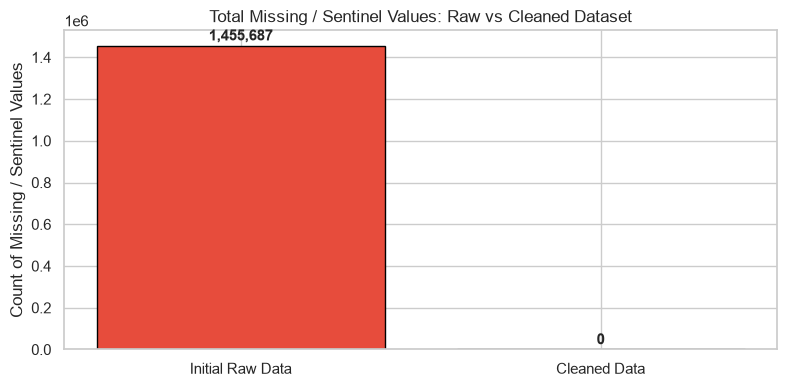

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Initial Raw Data", "Cleaned Data"], [sentinel_count_int, df_step4.isna().sum().sum()], color=["#e74c3c", "#27ae60"], edgecolor="black")
ax.set_title("Total Missing / Sentinel Values: Raw vs Cleaned Dataset")
ax.set_ylabel("Count of Missing / Sentinel Values")
for i, v in enumerate([sentinel_count_int, df_step4.isna().sum().sum()]):
    ax.text(i, v + 25000, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

# 10. Categorical Variables

We distinguish between identifier metadata columns and generalizable physical categorical variables:
- **Identifiers (High Cardinality)**: `EQID`, `Earthquake Name`, `Station Name`. These are labels and should NOT be one-hot encoded as predictive ML features.
- **Physical Categorical Features**:
  1. `Preferred NEHRP Based on Vs30`: Soil condition classification (classes A, B, C, D, E).
  2. `Mechanism Based on Rake Angle`: Seismological fault mechanism (0 = Strike-slip, 1 = Normal, 2 = Reverse, 3 = Reverse-oblique, 4 = Normal-oblique).

Below, we inspect the unique categories and show standard one-hot encoding on the site classification variable.

In [23]:
print("NEHRP Soil Classification Distribution:")
print(df_step4["Preferred NEHRP Based on Vs30"].value_counts())

print("\nFault Mechanism Distribution:")
print(df_step4["Mechanism Based on Rake Angle"].value_counts())

NEHRP Soil Classification Distribution:
Preferred NEHRP Based on Vs30
C      4516
D      3359
B       297
E       202
A         9
D/E       4
C/D       2
D-E       2
Name: count, dtype: int64

Fault Mechanism Distribution:
Mechanism Based on Rake Angle
2.0    3671
0.0    2992
3.0    1383
1.0     276
4.0      69
Name: count, dtype: int64


Standardizing hybrid NEHRP classes (e.g. grouping border classes `D/E` and `D-E` into `D`, `C/D` into `C`) and demonstrating one-hot encoding:

In [24]:
nehrp_clean = df_step4["Preferred NEHRP Based on Vs30"].astype(str).str.strip().replace({
    "D/E": "D",
    "D-E": "D",
    "C/D": "C"
})

nehrp_dummies = pd.get_dummies(nehrp_clean, prefix="NEHRP", drop_first=True, dtype=int)
nehrp_dummies.head()

,NEHRP_B,NEHRP_C,NEHRP_D,NEHRP_E
0,0,1,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


# 11. Numerical Feature Preparation

We evaluate the numerical properties (minimum, maximum, mean, and standard deviation) of the features intended for machine learning.

**Crucial Machine Learning Principle**:
Feature scaling (such as StandardScaler or MinMaxScaler) must **NOT** be applied to the entire dataset at this stage. Doing so would cause **Data Leakage**, as test-set statistics would influence the training transformation. Scaling should be fitted strictly on the training partition after the train/test split in the modeling phase.

In [25]:
ml_numeric_features = [
    "Earthquake Magnitude",
    "Hypocenter Depth (km)",
    "Strike (deg)",
    "Dip (deg)",
    "Rake Angle (deg)",
    "Vs30 (m/s) selected for analysis",
    "EpiD (km)",
    "HypD (km)",
    "Joyner-Boore Dist. (km)",
    "ClstD (km)",
    "PGA (g)",
    "PGV (cm/sec)",
    "PGD (cm)"
]

numeric_stats_table = pd.DataFrame({
    "Feature": ml_numeric_features,
    "Min": df_step4[ml_numeric_features].min().values,
    "Max": df_step4[ml_numeric_features].max().values,
    "Mean": df_step4[ml_numeric_features].mean().values,
    "Std Dev": df_step4[ml_numeric_features].std().values
})

numeric_stats_table

,Feature,Min,Max,Mean,Std Dev
0,Earthquake Magnitude,5.000000,7.9000,6.343268,0.751978
1,Hypocenter Depth (km),2.100000,81.0000,10.719880,3.924800
2,Strike (deg),0.000000,360.0000,187.658360,111.484748
3,Dip (deg),10.000000,90.0000,57.170695,22.018412
4,Rake Angle (deg),-180.000000,203.0000,58.198308,103.757300
5,Vs30 (m/s) selected for analysis,89.320000,2100.0000,419.779798,177.507351
6,EpiD (km),0.440000,1754.6800,143.212808,142.502587
7,HypD (km),5.020000,1754.7100,144.288976,141.898249
8,Joyner-Boore Dist. (km),0.000000,1532.6600,126.239577,122.069724
9,ClstD (km),0.050000,1532.6600,127.306787,121.490710


# 12. Outlier Analysis

In earthquake datasets, extreme observations are naturally occurring physical phenomena rather than sensor errors:
- Very high accelerations ($PGA > 1.0\text{ g}$) represent rare, destructive near-fault shockwaves (e.g. Tarzana station in the 1994 Northridge earthquake).
- Very large magnitudes ($M_w > 7.5$) represent major earthquakes (e.g. Chi-Chi, Hector Mine, Tohoku).
- High shear wave velocities ($Vs30 > 1500\text{ m/s}$) reflect hard crystalline bedrock sites.

Blindly deleting statistical outliers using arbitrary rules like $3\sigma$ or $1.5 \times IQR$ would discard the most critical, high-energy earthquake observations that ML models must learn. Therefore, records are retained because all values fall within physically valid geophysical boundaries.

In [26]:
pga_extreme = df_step4[df_step4["PGA (g)"] > 1.0]
print("Count of extreme PGA records (> 1.0 g):", len(pga_extreme))
print("Earthquakes with PGA > 1.0 g:", pga_extreme["Earthquake Name"].unique().tolist())

mag_extreme = df_step4[df_step4["Earthquake Magnitude"] >= 7.5]
print("Count of major earthquake records (Mw >= 7.5):", len(mag_extreme))
print("Major earthquakes:", mag_extreme["Earthquake Name"].unique().tolist())

Count of extreme PGA records (> 1.0 g): 14
Earthquakes with PGA > 1.0 g: ['San Fernando', 'Nahanni, Canada', 'Baja California', 'Cape Mendocino', 'Northridge-01', 'Parkfield-02, CA', 'Niigata, Japan', 'Chuetsu-oki', 'Iwate', 'Christchurch, New Zealand']
Count of major earthquake records (Mw >= 7.5): 724
Major earthquakes: ['Kocaeli, Turkey', 'Chi-Chi, Taiwan', 'Sitka, Alaska', 'St Elias, Alaska', 'Denali, Alaska', 'Wenchuan, China']


Visualizing the distribution of PGA on standard and logarithmic scales to demonstrate that extreme values follow a natural log-normal decay:

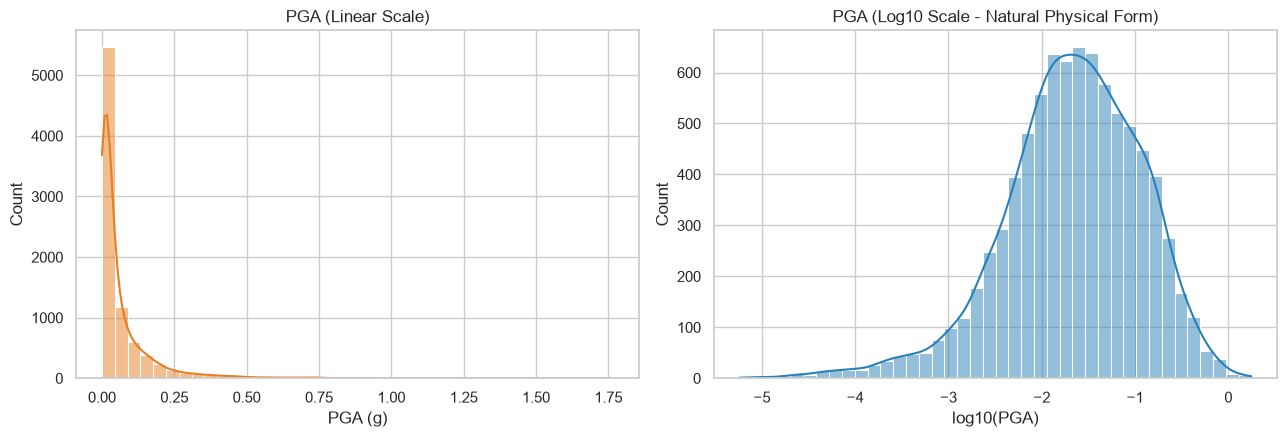

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df_step4["PGA (g)"], bins=40, kde=True, ax=axes[0], color="#e67e22")
axes[0].set_title("PGA (Linear Scale)")
axes[0].set_xlabel("PGA (g)")

sns.histplot(np.log10(df_step4["PGA (g)"]), bins=40, kde=True, ax=axes[1], color="#2980b9")
axes[1].set_title("PGA (Log10 Scale - Natural Physical Form)")
axes[1].set_xlabel("log10(PGA)")

plt.tight_layout()
plt.show()

# 13. Final Cleaned Dataset

We assign the cleaned dataset to the final variable name `cleaned_df`, reset the index, and verify its structure.

In [28]:
cleaned_df = df_step4.copy().reset_index(drop=True)

print("Cleaned DataFrame Shape:", cleaned_df.shape)
print("Remaining Missing Values Count:", cleaned_df.isna().sum().sum())
print("Duplicate Rows Count:", cleaned_df.duplicated().sum())
print("Columns Present in cleaned_df:")
print(cleaned_df.columns.tolist())

Cleaned DataFrame Shape: (8391, 24)
Remaining Missing Values Count: 0
Duplicate Rows Count: 0
Columns Present in cleaned_df:
['Record Sequence Number', 'EQID', 'Earthquake Name', 'YEAR', 'Station Name', 'Station Latitude', 'Station Longitude', 'Earthquake Magnitude', 'Hypocenter Depth (km)', 'Hypocenter Latitude (deg)', 'Hypocenter Longitude (deg)', 'Strike (deg)', 'Dip (deg)', 'Rake Angle (deg)', 'Mechanism Based on Rake Angle', 'Vs30 (m/s) selected for analysis', 'Preferred NEHRP Based on Vs30', 'EpiD (km)', 'HypD (km)', 'Joyner-Boore Dist. (km)', 'ClstD (km)', 'PGA (g)', 'PGV (cm/sec)', 'PGD (cm)']


Displaying the first 5 records of `cleaned_df`:

In [29]:
cleaned_df.head()

,Record Sequence Number,EQID,Earthquake Name,YEAR,Station Name,Station Latitude,Station Longitude,Earthquake Magnitude,Hypocenter Depth (km),Hypocenter Latitude (deg),...,Mechanism Based on Rake Angle,Vs30 (m/s) selected for analysis,Preferred NEHRP Based on Vs30,EpiD (km),HypD (km),Joyner-Boore Dist. (km),ClstD (km),PGA (g),PGV (cm/sec),PGD (cm)
0,1,1.0,"Helena, Montana-01",1935.0,Carroll College,46.580,-112.030,6.0,6.0,46.61,...,0.0,593.35,C,6.31,8.71,2.07,2.86,0.157020,10.05400,3.005200
1,2,2.0,"Helena, Montana-02",1935.0,Helena Fed Bldg,46.590,-112.040,6.0,6.0,46.62,...,0.0,551.82,C,6.31,8.71,2.09,2.92,0.046423,0.64978,0.035305
2,3,3.0,Humbolt Bay,1937.0,Ferndale City Hall,40.576,-124.263,5.8,10.0,40.40,...,0.0,219.31,D,73.49,74.17,71.28,71.57,0.040961,2.79070,0.402240
3,4,4.0,Imperial Valley-01,1938.0,El Centro Array #9,32.794,-115.549,5.0,16.0,32.90,...,0.0,213.44,D,33.20,36.86,32.44,34.98,0.018449,0.64551,0.056359
4,5,5.0,Northwest Calif-01,1938.0,Ferndale City Hall,40.576,-124.263,5.5,10.0,40.30,...,0.0,219.31,D,54.88,55.78,52.73,53.58,0.122180,6.56390,0.733060


# 14. Final Data Quality Report

A compact comparison summarizing the transformation from the raw Excel flatfile to the cleaned dataset:

In [30]:
quality_report = pd.DataFrame({
    "Metric": [
        "Original Rows",
        "Final Cleaned Rows",
        "Original Columns",
        "Final Cleaned Columns",
        "Duplicate Rows Removed",
        "Non-Significant / Incomplete Rows Removed",
        "Columns Removed (Spectral / High Missing / Constant)",
        "Missing Values Remaining",
        "Important Features Retained"
    ],
    "Value": [
        raw_df.shape[0],
        cleaned_df.shape[0],
        raw_df.shape[1],
        cleaned_df.shape[1],
        0,
        raw_df.shape[0] - cleaned_df.shape[0],
        raw_df.shape[1] - cleaned_df.shape[1],
        cleaned_df.isna().sum().sum(),
        len(cleaned_df.columns)
    ]
})

quality_report

,Metric,Value
0,Original Rows,21540
1,Final Cleaned Rows,8391
2,Original Columns,274
3,Final Cleaned Columns,24
4,Duplicate Rows Removed,0
5,Non-Significant / Incomplete Rows Removed,13149
6,Columns Removed (Spectral / High Missing / Con...,250
7,Missing Values Remaining,0
8,Important Features Retained,24


# 15. Final Visualizations

We generate key project-specific visualizations to illustrate fundamental physical relationships:
1. Distance distributions ($ClstD$, $HypD$, $Joyner-Boore$).
2. Peak Ground Motion distributions ($PGA$, $PGV$).
3. Soil velocity ($Vs30$) distribution by NEHRP site class.
4. Physical relationships: Magnitude vs PGA and Distance vs PGA (attenuation curve).
5. Correlation heatmap across selected continuous seismological variables.

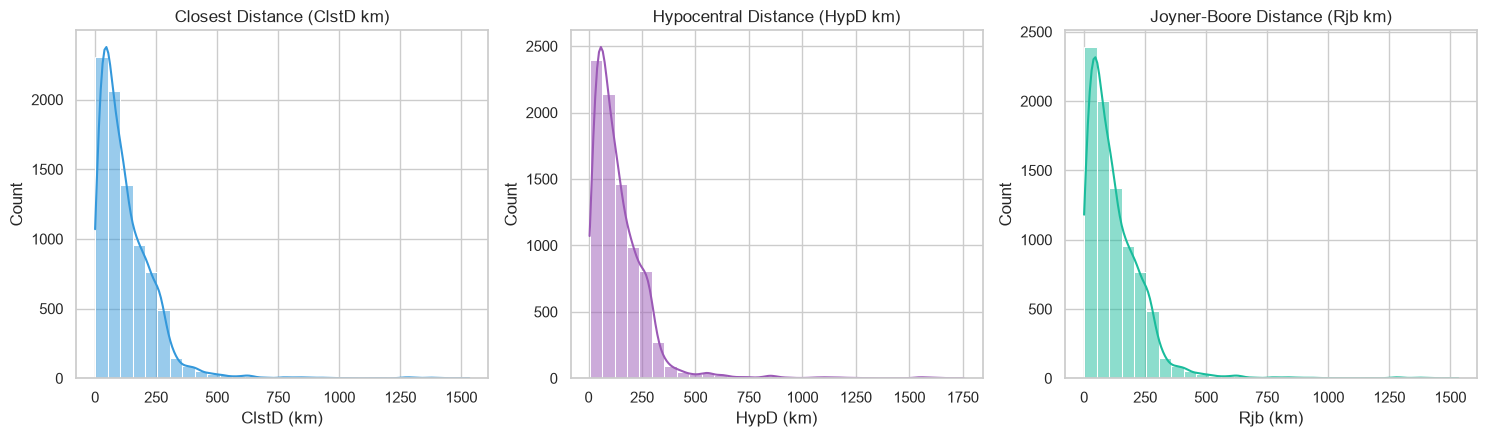

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(cleaned_df["ClstD (km)"], bins=30, kde=True, ax=axes[0], color="#3498db")
axes[0].set_title("Closest Distance (ClstD km)")
axes[0].set_xlabel("ClstD (km)")

sns.histplot(cleaned_df["HypD (km)"], bins=30, kde=True, ax=axes[1], color="#9b59b6")
axes[1].set_title("Hypocentral Distance (HypD km)")
axes[1].set_xlabel("HypD (km)")

sns.histplot(cleaned_df["Joyner-Boore Dist. (km)"], bins=30, kde=True, ax=axes[2], color="#1abc9c")
axes[2].set_title("Joyner-Boore Distance (Rjb km)")
axes[2].set_xlabel("Rjb (km)")

plt.tight_layout()
plt.show()

Visualizing PGA and PGV distributions:

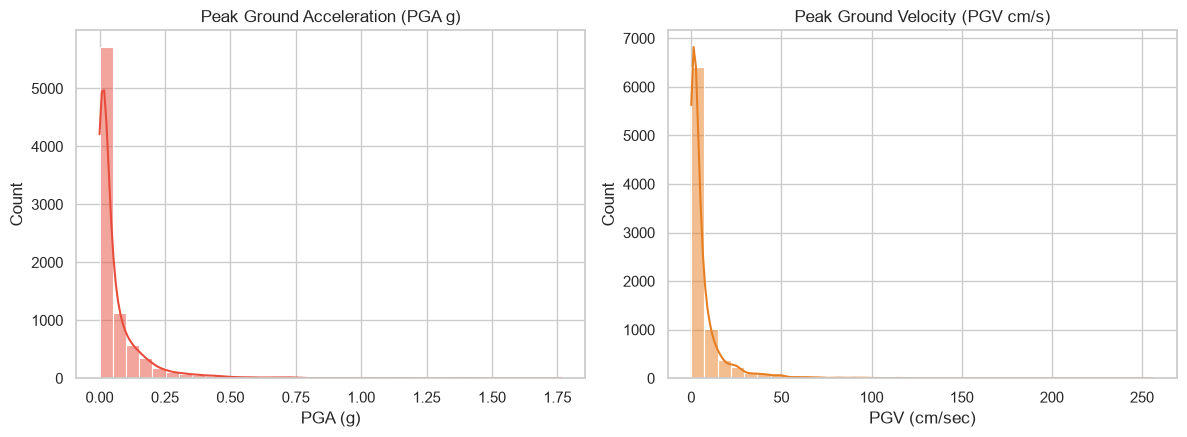

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(cleaned_df["PGA (g)"], bins=35, kde=True, ax=axes[0], color="#e74c3c")
axes[0].set_title("Peak Ground Acceleration (PGA g)")
axes[0].set_xlabel("PGA (g)")

sns.histplot(cleaned_df["PGV (cm/sec)"], bins=35, kde=True, ax=axes[1], color="#e67e22")
axes[1].set_title("Peak Ground Velocity (PGV cm/s)")
axes[1].set_xlabel("PGV (cm/sec)")

plt.tight_layout()
plt.show()

Visualizing $Vs30$ distribution across NEHRP site classes:

/var/folders/ph/_r14btld1ydffx34nrtxmjsh0000gn/T/ipykernel_7493/3849230799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Preferred NEHRP Based on Vs30", y="Vs30 (m/s) selected for analysis", data=valid_nehrp, order=["A", "B", "C", "D", "E"], palette="Set2")


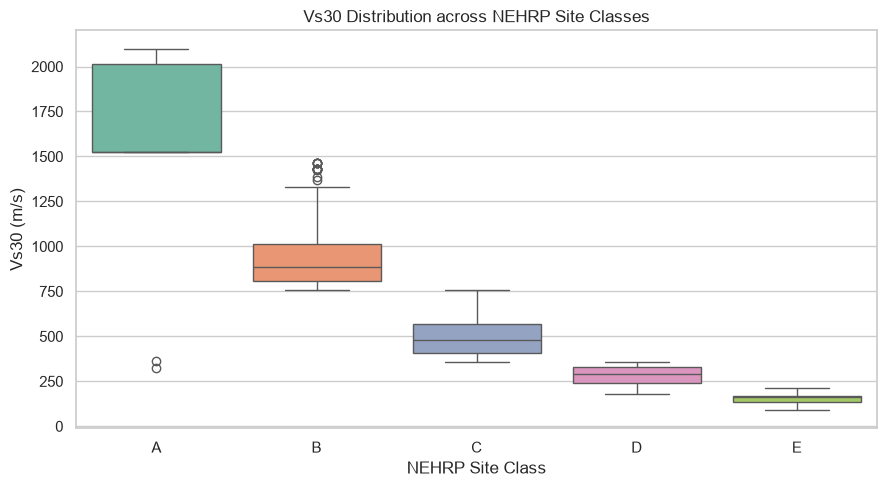

In [33]:
valid_nehrp = cleaned_df[cleaned_df["Preferred NEHRP Based on Vs30"].isin(["A", "B", "C", "D", "E"])]

plt.figure(figsize=(9, 5))
sns.boxplot(x="Preferred NEHRP Based on Vs30", y="Vs30 (m/s) selected for analysis", data=valid_nehrp, order=["A", "B", "C", "D", "E"], palette="Set2")
plt.title("Vs30 Distribution across NEHRP Site Classes")
plt.xlabel("NEHRP Site Class")
plt.ylabel("Vs30 (m/s)")
plt.tight_layout()
plt.show()

Physical relationships: Magnitude vs PGA and Distance vs PGA (demonstrating attenuation with distance):

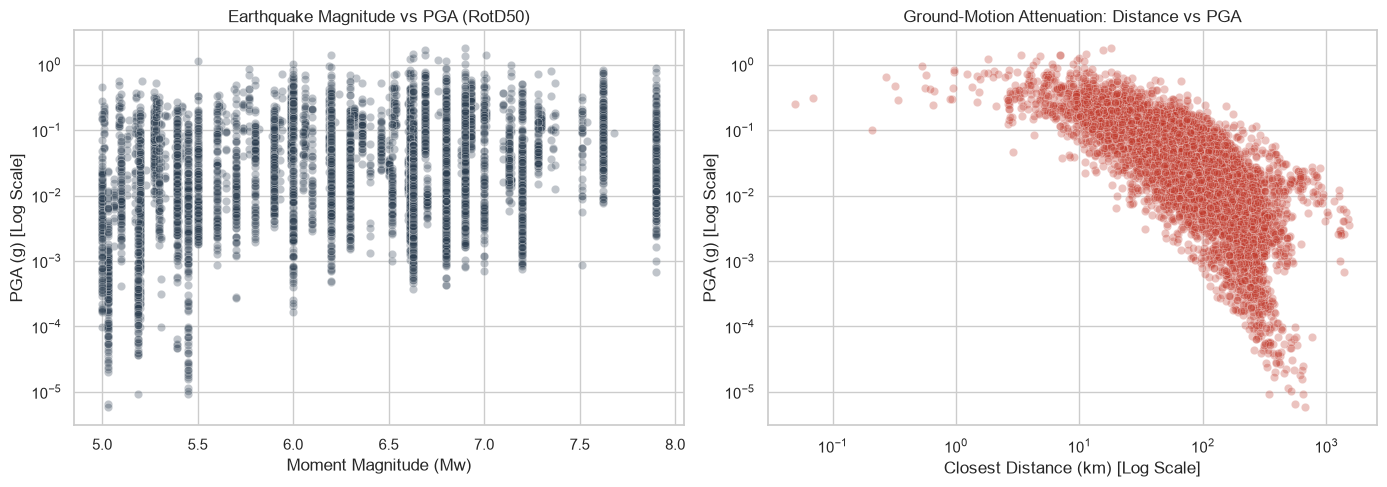

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x="Earthquake Magnitude", y="PGA (g)", data=cleaned_df, alpha=0.3, color="#2c3e50", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Earthquake Magnitude vs PGA (RotD50)")
axes[0].set_xlabel("Moment Magnitude (Mw)")
axes[0].set_ylabel("PGA (g) [Log Scale]")

sns.scatterplot(x="ClstD (km)", y="PGA (g)", data=cleaned_df, alpha=0.3, color="#c0392b", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_title("Ground-Motion Attenuation: Distance vs PGA")
axes[1].set_xlabel("Closest Distance (km) [Log Scale]")
axes[1].set_ylabel("PGA (g) [Log Scale]")

plt.tight_layout()
plt.show()

Correlation heatmap across selected numerical earthquake features:

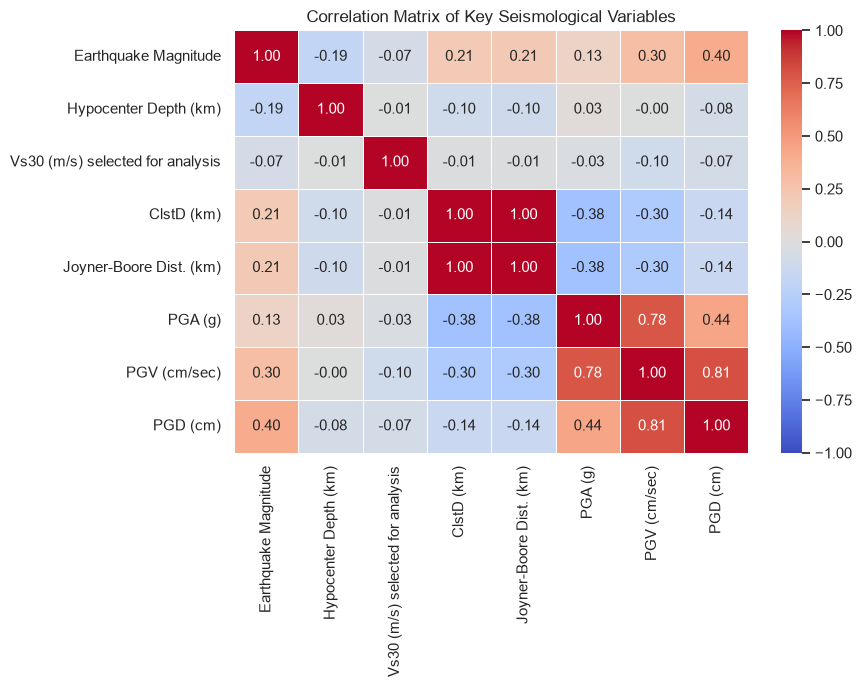

In [35]:
corr_features = [
    "Earthquake Magnitude",
    "Hypocenter Depth (km)",
    "Vs30 (m/s) selected for analysis",
    "ClstD (km)",
    "Joyner-Boore Dist. (km)",
    "PGA (g)",
    "PGV (cm/sec)",
    "PGD (cm)"
]

corr_matrix = cleaned_df[corr_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Key Seismological Variables")
plt.tight_layout()
plt.show()

# 16. Save the Cleaned Dataset

We save `cleaned_df` to a new CSV file named `cleaned_NGA_West2_d050.csv` in the current project directory. The original Excel file remains completely untouched.

In [36]:
output_filename = "dataset/cleaned_dataset_NGA_West2_d050.csv"
cleaned_df.to_csv(output_filename, index=False)
print("Cleaned dataset successfully saved to:", output_filename)

Cleaned dataset successfully saved to: dataset/cleaned_dataset_NGA_West2_d050.csv


Verifying that the exported file exists and checking its size and content:

In [37]:
verify_df = pd.read_csv(output_filename)
print("Verification Shape:", verify_df.shape)
print("Verification Missing Values:", verify_df.isna().sum().sum())

Verification Shape: (8391, 24)
Verification Missing Values: 0


# 17. Final Summary

### 1. What Was Cleaned and Diagnostic Findings
- **Sentinel Missing Value Replacement**: In NGA-West2 flatfiles, missing or unmeasured quantities are encoded with the sentinel code `-999` rather than standard blank cells. We mapped all instances of `-999` to `NaN` so that true missingness could be analyzed.
- **Deduplication**: Verified that no duplicate rows or duplicate `Record Sequence Numbers` exist.
- **Engineering Significance Filtering**: Applied the domain filter established in the reference paper (Poulos & Silva-Lopez, 2020), retaining records with $M_w \ge 5.0$. This filtered out 13,045 non-damaging micro-earthquake records and invalid magnitude entries.
- **Completeness Filtering**: Removed records missing ground-motion intensities (`PGA`, `PGV`, `PGD`) or primary distance/site measurements (`ClstD`, `Vs30`, `Hypocenter Depth`).
- **Feature Pruning**: Excluded 111 response spectra period columns (`T0.010S` to `T20.000S`), 45 columns with >80% missing data, constant columns, and unassigned placeholder columns.

### 2. Retained Features and Data Dimensions
- **Final Rows**: 8,391 high-quality, physically verified seismic records.
- **Final Columns**: 24 well-defined features covering earthquake source properties, propagation distances, site soil parameters, station coordinates, and ground-motion intensities.
- **Data Integrity**: Exactly 0 missing values remain across all retained features.
- **Outlier Handling**: Extreme values (such as $PGA > 1.0\text{ g}$ or $M_w \ge 7.5$) were verified as genuine physical earthquake observations and retained.

### 3. Ground-Motion Directionality ($\Delta\theta$) Assessment
- **Status of $\Delta\theta$ in this Flatfile**: This flatfile is the **RotD50** public version, which provides median horizontal ground-motion intensities across all rotation angles.
- **Why $\Delta\theta$ is NOT Created**: Directionality ($\Delta\theta = |\theta_i - \theta_j|$) is the difference between angles of *maximum* ground-motion intensity ($\text{RotD100}$) at two sites. In the reference paper, Poulos & Silva-Lopez explicitly state that they had to compute $\theta$ by processing the raw acceleration time-series waveforms because orientation angles are not provided in the flatfile.
- **`Theta.D` Distinction**: The column `Theta.D (deg)` in the flatfile represents the directivity model azimuth angle (Somerville / Spudich directivity model) between the fault rupture propagation vector and the source-to-site vector. It is **not** the angle of maximum ground shaking and must not be used as $\Delta\theta$.
- In accordance with academic rigor, $\Delta\theta$ is not invented.

### 4. Next Steps for Team Members
With `cleaned_NGA_West2_d050.csv` ready, the next phases of the project are:
1. **Station Pairing**: Group records by `EQID` to pair stations that recorded the same earthquake event.
2. **Spatial Separation Distance ($d$)**: Compute inter-station distances using station latitudes and longitudes (e.g. limiting to $d \le 5\text{ km}$ as in the reference paper).
3. **Model Training & Evaluation**: Train Ridge Regression and Neural Network models, tune the regularization hyperparameter $\alpha$, and evaluate performance using $R^2$ and RMSE metrics.